In [ ]:
!pip install yfinance statsmodels

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Loading the data

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_clean.csv to data_clean.csv


In [ ]:
df = pd.read_csv("data_clean.csv", index_col=0, parse_dates=True)
print(df.shape)
df.head()

(2410, 8)


,BTC-USD,^GSPC,^VIX,DX-Y.NYB,US10Y,BREAKEVEN,BTC_ret,SPX_ret
2017-01-04,1154.729980,2270.750000,11.85,102.699997,2.46,1.99,0.106233,0.005722
2017-01-05,1013.380005,2269.000000,11.67,101.519997,2.37,1.95,-0.122410,-0.000771
2017-01-06,902.200989,2276.979980,11.32,102.220001,2.42,1.96,-0.109711,0.003517
2017-01-09,902.828003,2268.899902,11.56,101.930000,2.38,1.95,0.000695,-0.003549
2017-01-10,907.679016,2268.899902,11.49,102.010002,2.38,1.95,0.005373,0.000000


# Rolling Regression

In [ ]:
# Number of trading days in 1 year
window = 250

# Independent variables (macro factors)
x_vars = ["SPX_ret", "^VIX", "DX-Y.NYB", "US10Y", "BREAKEVEN"]

# Dependent variable
y_var = "BTC_ret"

# We store the beta coefficient for each variable at each date
# In the dictionary, each key is one of the x varaibles and its value will be a list of the beta coefficients caluclated at that point in time
results = {var: [] for var in x_vars}

# A list to store the dates corresponding to each calculated set of beta coefficients
dates = []

for i in range(window, len(df)):
    window_data = df.iloc[i-window:i]

    y = window_data[y_var]
    x = sm.add_constant(window_data[x_vars])

    model = sm.OLS(y, x).fit()

    # After regression, loop to go through each x varaible, extract the caluclated beta coefficient and appened it to the dictionary
    for var in x_vars:
        results[var].append(model.params[var])

    dates.append(df.index[i])

# Convert to a DataFrame
betas = pd.DataFrame(results, index=dates)

print("Rolling regressions complete")
print(f"Number of windows: {len(betas)}")
betas.head()

Rolling regressions complete
Number of windows: 2160


,SPX_ret,^VIX,DX-Y.NYB,US10Y,BREAKEVEN
2017-12-20,0.683340,0.001574,-0.002932,0.013159,0.029059
2017-12-21,0.604249,0.001506,-0.002901,0.000602,0.032503
2017-12-22,0.544987,0.001336,-0.002413,-0.009383,0.033478
2017-12-25,0.685572,0.001289,-0.001702,-0.020043,0.027535
2017-12-26,0.683984,0.001285,-0.001696,-0.020135,0.027529


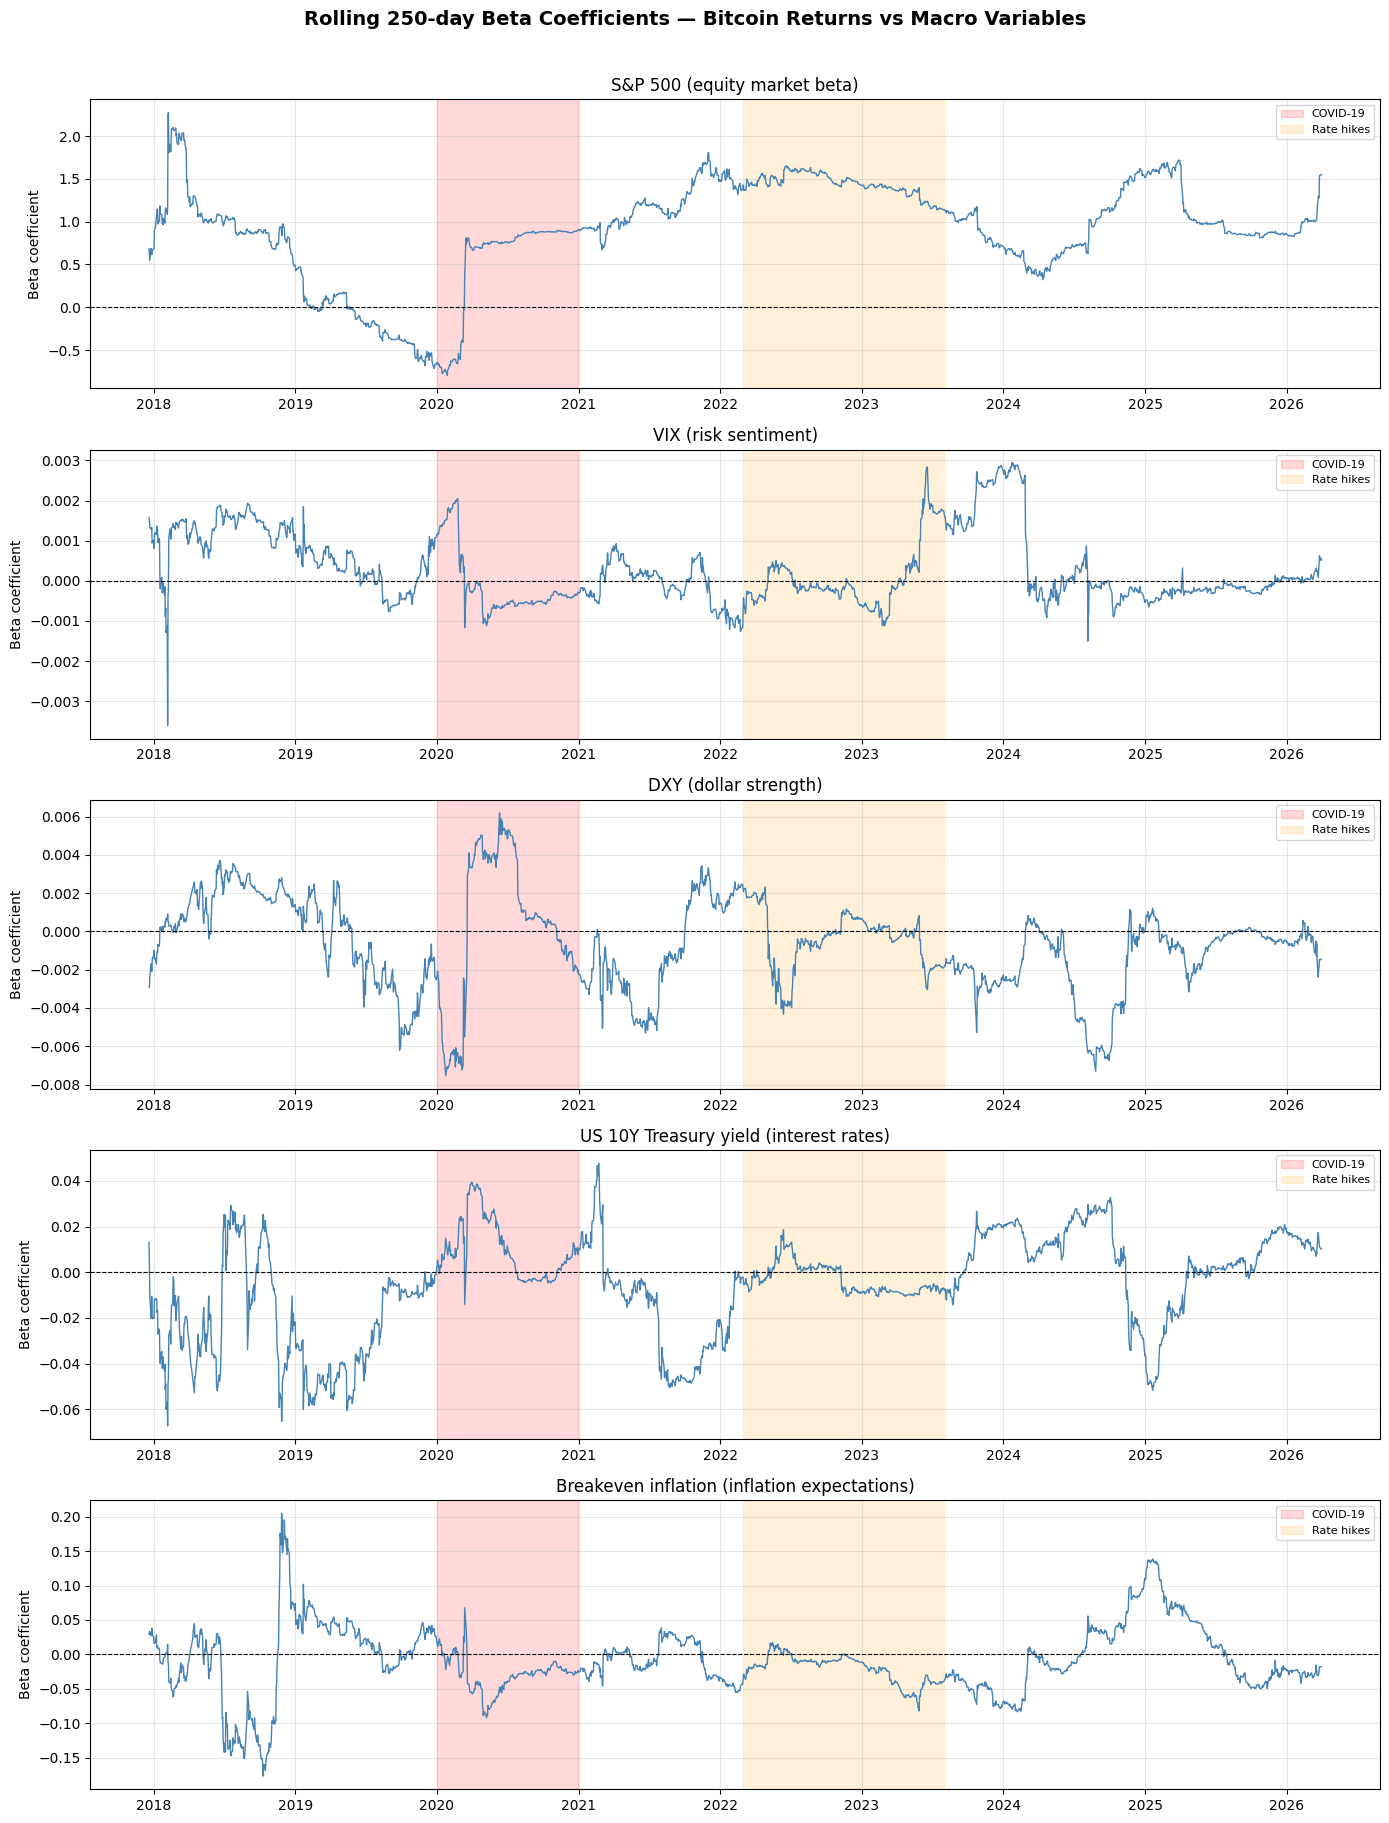

Saved as rolling_betas.png


In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18))

titles = {
    "SPX_ret":   "S&P 500 (equity market beta)",
    "^VIX":       "VIX (risk sentiment)",
    "DX-Y.NYB":       "DXY (dollar strength)",
    "US10Y":     "US 10Y Treasury yield (interest rates)",
    "BREAKEVEN": "Breakeven inflation (inflation expectations)"
}

for ax, var in zip(axes, x_vars):
    ax.plot(betas.index, betas[var], color="steelblue", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

    # Shade the COVID period
    ax.axvspan("2020-01-01", "2020-12-31", alpha=0.15, color="red", label="COVID-19")

    # Shade the rate hiking period
    ax.axvspan("2022-03-01", "2023-07-31", alpha=0.15, color="orange", label="Rate hikes")

    ax.set_title(titles[var], fontsize=12)
    ax.set_ylabel("Beta coefficient")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Rolling 250-day Beta Coefficients — Bitcoin Returns vs Macro Variables",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("rolling_betas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as rolling_betas.png")